In [706]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tbats import TBATS
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsforecast import StatsForecast
from statsforecast.models import AutoTBATS
import warnings
warnings.filterwarnings('ignore')
import re

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Librerías importadas correctamente")

NumPy version: 2.4.6
Pandas version: 3.0.3
Librerías importadas correctamente


In [707]:
ruta_excel_matriz = "./Datos/df_matriz_ventas_articulos_forecast.xlsx"
df=pd.read_excel(ruta_excel_matriz)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   codigo_articulo           450 non-null    str    
 1   descripcion_completa      449 non-null    str    
 2   grupo_articulo            450 non-null    str    
 3   categoria                 411 non-null    str    
 4   subcategoria              411 non-null    str    
 5   tipo                      406 non-null    str    
 6   marca_fabricante          450 non-null    str    
 7   unidad_medida_inventario  450 non-null    str    
 8   cluster_kmeans_final      448 non-null    float64
 9   descripcion_cluster       448 non-null    str    
 10  venta_2024_01             450 non-null    float64
 11  venta_2024_02             450 non-null    float64
 12  venta_2024_03             450 non-null    float64
 13  venta_2024_04             450 non-null    float64
 14  venta_2024_05        

In [708]:
df.head()

,codigo_articulo,descripcion_completa,grupo_articulo,categoria,subcategoria,tipo,marca_fabricante,unidad_medida_inventario,cluster_kmeans_final,descripcion_cluster,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
0,0225-3M,"Manga de sincronismo, 225-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,1.0,"Demanda históricamente relevante, variable y c...",...,6.0,12.0,0.0,0.0,24.0,0.0,0.0,24.0,9.0,0.0
1,0270H,"Manga de sincronismo, 270H, longitud externa 2...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,2.0,Demanda activa y reciente con señales de creci...,...,50.0,600.0,225.0,150.0,38.0,200.0,19.0,0.0,300.0,350.0
2,0384-3M-JASON,"Manga de sincronismo, 384-3M, Longitud externa...",FAJAS,CORREAS,SINCRONISMO,DIENTE CURVILINEO,JASON,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,15.0,30.0,55.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0390H-JASON,"Manga de sincronismo, 390H, longitud externa 3...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,JASON,MM,2.0,Demanda activa y reciente con señales de creci...,...,0.0,0.0,0.0,0.0,25.0,0.0,201.0,25.0,140.0,0.0
4,0420H,"Manga de sincronismo, 420H, longitud externa 4...",FAJAS,CORREAS,SINCRONISMO,DIENTE TRAPEZOIDAL,BANDO,MM,0.0,Demanda con picos frecuentes y variabilidad co...,...,38.0,0.0,0.0,50.0,0.0,0.0,19.0,0.0,0.0,0.0


In [709]:
lista_columnas_numericas = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
print(f"Columnas numéricas del DataFrame: {lista_columnas_numericas}")
print(f" longitud de la lista de columnas numéricas: {len(lista_columnas_numericas)}")
lista_col_ventas = [col for col in df.columns if col.startswith('venta_')]
print(f"Columnas de ventas del DataFrame: {lista_col_ventas}")


Columnas numéricas del DataFrame: ['cluster_kmeans_final', 'venta_2024_01', 'venta_2024_02', 'venta_2024_03', 'venta_2024_04', 'venta_2024_05', 'venta_2024_06', 'venta_2024_07', 'venta_2024_08', 'venta_2024_09', 'venta_2024_10', 'venta_2024_11', 'venta_2024_12', 'venta_2025_01', 'venta_2025_02', 'venta_2025_03', 'venta_2025_04', 'venta_2025_05', 'venta_2025_06', 'venta_2025_07', 'venta_2025_08', 'venta_2025_09', 'venta_2025_10', 'venta_2025_11', 'venta_2025_12', 'venta_2026_01', 'venta_2026_02', 'venta_2026_03', 'venta_2026_04', 'venta_2026_05', 'venta_2026_06', 'venta_2026_07']
 longitud de la lista de columnas numéricas: 32
Columnas de ventas del DataFrame: ['venta_2024_01', 'venta_2024_02', 'venta_2024_03', 'venta_2024_04', 'venta_2024_05', 'venta_2024_06', 'venta_2024_07', 'venta_2024_08', 'venta_2024_09', 'venta_2024_10', 'venta_2024_11', 'venta_2024_12', 'venta_2025_01', 'venta_2025_02', 'venta_2025_03', 'venta_2025_04', 'venta_2025_05', 'venta_2025_06', 'venta_2025_07', 'venta_2

In [710]:
df_ventas=df[lista_col_ventas + ["codigo_articulo"]]
df_ventas.set_index("codigo_articulo", inplace=True)
df_ventas.head(10)

,venta_2024_01,venta_2024_02,venta_2024_03,venta_2024_04,venta_2024_05,venta_2024_06,venta_2024_07,venta_2024_08,venta_2024_09,venta_2024_10,...,venta_2025_10,venta_2025_11,venta_2025_12,venta_2026_01,venta_2026_02,venta_2026_03,venta_2026_04,venta_2026_05,venta_2026_06,venta_2026_07
codigo_articulo,,,,,,,,,,,,,,,,,,,,,
0225-3M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,0.0,...,6.0,12.0,0.0,0.0,24.0,0.0,0.0,24.0,9.0,0.0
0270H,0.0,0.0,0.0,0.0,10.0,0.0,482.0,0.0,10.0,0.0,...,50.0,600.0,225.0,150.0,38.0,200.0,19.0,0.0,300.0,350.0
0384-3M-JASON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.0,30.0,55.0,45.0,0.0,0.0,0.0,0.0,0.0,0.0
0390H-JASON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,25.0,0.0,201.0,25.0,140.0,0.0
0420H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,...,38.0,0.0,0.0,50.0,0.0,0.0,19.0,0.0,0.0,0.0
0475-5M,0.0,0.0,0.0,0.0,30.0,0.0,95.0,85.0,0.0,0.0,...,180.0,30.0,0.0,0.0,0.0,0.0,580.0,0.0,0.0,0.0
0475-5M-JASON,0.0,100.0,75.0,30.0,30.0,0.0,30.0,0.0,0.0,0.0,...,150.0,0.0,30.0,0.0,0.0,0.0,22.0,0.0,20.0,0.0
0480-3M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0,20.0,...,0.0,0.0,0.0,80.0,11.0,80.0,0.0,0.0,0.0,0.0
0510H-JASON,164.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,...,0.0,76.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [711]:
# ============================================================
# 1. Detectar columnas mensuales de venta
# ============================================================

def obtener_columnas_venta_ordenadas(df):
    """
    Detecta columnas tipo venta_YYYY_MM y las ordena cronológicamente.
    """

    patron = r"^venta_\d{4}_\d{2}$"

    columnas_venta = [
        col for col in df.columns
        if re.match(patron, str(col))
    ]

    columnas_venta = sorted(
        columnas_venta,
        key=lambda col: pd.to_datetime(
            col.replace("venta_", "") + "_01",
            format="%Y_%m_%d"
        )
    )

    return columnas_venta


def columna_venta_a_fecha(columna):
    """
    Convierte una columna tipo venta_2024_01 a fecha fin de mes.
    """

    fecha = pd.to_datetime(
        columna.replace("venta_", "") + "_01",
        format="%Y_%m_%d"
    ) + pd.offsets.MonthEnd(0)

    return fecha

In [712]:
columnas_venta = obtener_columnas_venta_ordenadas(df_ventas)

print("Cantidad de columnas de venta:")
print(len(columnas_venta))

print("Primera columna:")
print(columnas_venta[0])

print("Última columna:")
print(columnas_venta[-1])

Cantidad de columnas de venta:
31
Primera columna:
venta_2024_01
Última columna:
venta_2026_07


In [713]:

# 2. Convertir matriz mensual a formato largo
# ============================================================

def convertir_matriz_a_formato_largo(df_ventas, columnas_venta):
    """
    Convierte la matriz mensual por artículo a formato largo:
    codigo_articulo | columna_venta | fecha_mes | venta_mensual
    """

    df_temp = df_ventas.copy()

    if "codigo_articulo" not in df_temp.columns:
        df_temp = df_temp.reset_index()

    columnas_id = [
        col for col in df_temp.columns
        if col not in columnas_venta
    ]

    df_long = df_temp.melt(
        id_vars=columnas_id,
        value_vars=columnas_venta,
        var_name="columna_venta",
        value_name="venta_mensual"
    )

    df_long["fecha_mes"] = df_long["columna_venta"].apply(
        columna_venta_a_fecha
    )

    df_long["venta_mensual"] = pd.to_numeric(
        df_long["venta_mensual"],
        errors="coerce"
    ).fillna(0)

    df_long = df_long.sort_values(
        by=["codigo_articulo", "fecha_mes"]
    ).reset_index(drop=True)

    return df_long

In [714]:
df_series_long = convertir_matriz_a_formato_largo(
    df_ventas=df_ventas,
    columnas_venta=columnas_venta
)

df_series_long.head(31)

,codigo_articulo,columna_venta,venta_mensual,fecha_mes
0,0225-3M,venta_2024_01,0.0,2024-01-31
1,0225-3M,venta_2024_02,0.0,2024-02-29
2,0225-3M,venta_2024_03,0.0,2024-03-31
3,0225-3M,venta_2024_04,0.0,2024-04-30
4,0225-3M,venta_2024_05,0.0,2024-05-31
5,0225-3M,venta_2024_06,0.0,2024-06-30
6,0225-3M,venta_2024_07,0.0,2024-07-31
7,0225-3M,venta_2024_08,18.0,2024-08-31
8,0225-3M,venta_2024_09,0.0,2024-09-30
9,0225-3M,venta_2024_10,0.0,2024-10-31


In [715]:
df_series_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 13950 entries, 0 to 13949
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   codigo_articulo  13950 non-null  str           
 1   columna_venta    13950 non-null  str           
 2   venta_mensual    13950 non-null  float64       
 3   fecha_mes        13950 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 738.0 KB


In [716]:
df_codigo_ejemplo=df_series_long[df_series_long["codigo_articulo"] == "UCM36LPSS12"]
df_codigo_ejemplo=df_codigo_ejemplo.sort_values(by="fecha_mes").reset_index(drop=True).copy()
df_codigo_ejemplo

,codigo_articulo,columna_venta,venta_mensual,fecha_mes
0,UCM36LPSS12,venta_2024_01,0.0,2024-01-31
1,UCM36LPSS12,venta_2024_02,0.0,2024-02-29
2,UCM36LPSS12,venta_2024_03,4.0,2024-03-31
3,UCM36LPSS12,venta_2024_04,6.0,2024-04-30
4,UCM36LPSS12,venta_2024_05,7.0,2024-05-31
5,UCM36LPSS12,venta_2024_06,0.0,2024-06-30
6,UCM36LPSS12,venta_2024_07,0.0,2024-07-31
7,UCM36LPSS12,venta_2024_08,0.0,2024-08-31
8,UCM36LPSS12,venta_2024_09,4.0,2024-09-30
9,UCM36LPSS12,venta_2024_10,1.0,2024-10-31


Entrenamiento: 24 observaciones (0 a 23)
Prueba: 7 observaciones (24 a 30)


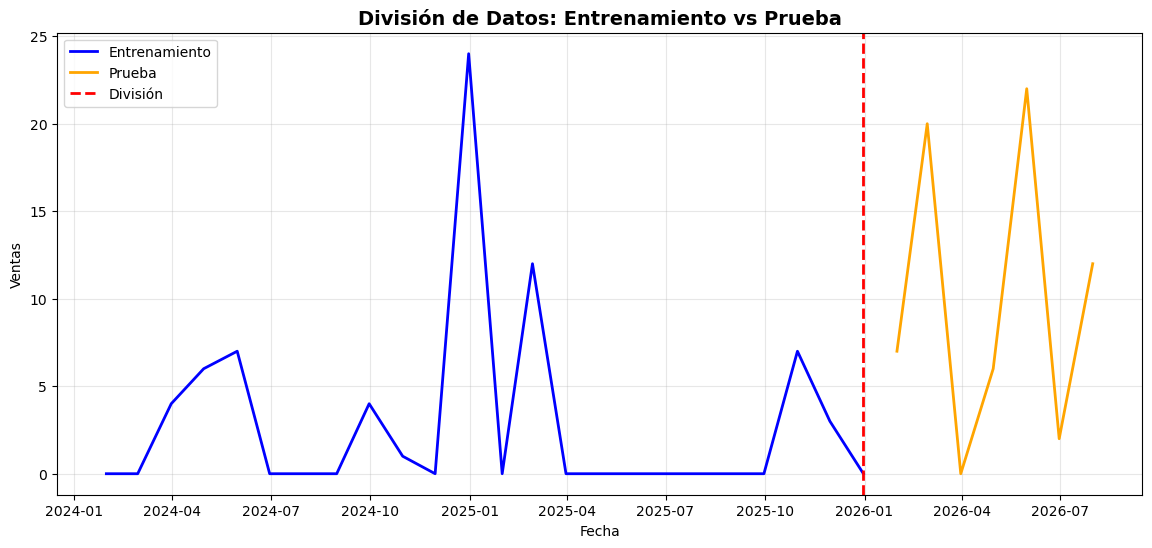

In [717]:
# Dividir en entrenamiento (80%) y prueba (20%)
train_size = int(len(df_codigo_ejemplo) * 0.8)
train_time = df_codigo_ejemplo.iloc[:train_size]['fecha_mes'].values
train_data = df_codigo_ejemplo.iloc[:train_size]['venta_mensual'].values
test_data = df_codigo_ejemplo.iloc[train_size:]['venta_mensual'].values
test_time = df_codigo_ejemplo.iloc[train_size:]['fecha_mes'].values
test_index = df_codigo_ejemplo.iloc[train_size:].index
corte=df_codigo_ejemplo.iloc[train_size-1]['fecha_mes']

print(f"Entrenamiento: {train_size} observaciones ({df_codigo_ejemplo.index[0]} a {df_codigo_ejemplo.index[train_size-1]})")
print(f"Prueba: {len(test_data)} observaciones ({test_index[0]} a {test_index[-1]})")

# Visualizar la división
plt.figure(figsize=(14, 6))
plt.plot(train_time, train_data, label='Entrenamiento', linewidth=2, color='blue')
plt.plot(test_time, test_data, label='Prueba', linewidth=2, color='orange')
plt.axvline(x=corte, color='red', linestyle='--', linewidth=2, label='División')
plt.title('División de Datos: Entrenamiento vs Prueba', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [718]:
# ============================================================
# Preparar dataframe para StatsForecast
# ============================================================

df_sf = df_series_long.rename(
    columns={
        "codigo_articulo": "unique_id",
        "fecha_mes": "ds",
        "venta_mensual": "y"
    }
)[["unique_id", "ds", "y"]].copy()

df_sf["ds"] = pd.to_datetime(df_sf["ds"])
df_sf["y"] = pd.to_numeric(df_sf["y"], errors="coerce").fillna(0)

df_sf = df_sf.sort_values(["unique_id", "ds"]).reset_index(drop=True)

df_sf.head()

,unique_id,ds,y
0,0225-3M,2024-01-31,0.0
1,0225-3M,2024-02-29,0.0
2,0225-3M,2024-03-31,0.0
3,0225-3M,2024-04-30,0.0
4,0225-3M,2024-05-31,0.0


In [719]:
# ============================================================
# Separar train/test para evaluación
# ============================================================

horizonte_meses=6

fechas_ordenadas = df_sf["ds"].sort_values().unique()

fechas_test = fechas_ordenadas[-horizonte_meses:]
fechas_train = fechas_ordenadas[:-horizonte_meses]


df_train = df_sf[df_sf["ds"].isin(fechas_train)].copy()
df_test = df_sf[df_sf["ds"].isin(fechas_test)].copy()

print("Rango de fechas en el conjunto de entrenamiento:")
print(f"  - Inicio: {df_train['ds'].min()}")
print(f"  - Fin: {df_train['ds'].max()}")

print("\nRango de fechas en el conjunto de prueba:")
print(f"  - Inicio: {df_test['ds'].min()}")
print(f"  - Fin: {df_test['ds'].max()}")

Rango de fechas en el conjunto de entrenamiento:
  - Inicio: 2024-01-31 00:00:00
  - Fin: 2026-01-31 00:00:00

Rango de fechas en el conjunto de prueba:
  - Inicio: 2026-02-28 00:00:00
  - Fin: 2026-07-31 00:00:00


In [720]:
# ============================================================
# Promedio de venta mensual por código en período train
# ============================================================
def calculo_venta_promedio_train_Xmeses(df_train, meses=24):
    """
    Calcula el promedio de venta mensual por código de artículo en el período de entrenamiento.
    """
    df_temp = df_train.copy()

    # Asegurar formato fecha
    df_temp["ds"] = pd.to_datetime(df_temp["ds"])

    # Asegurar formato numérico
    df_temp["y"] = pd.to_numeric(df_temp["y"], errors="coerce").fillna(0)

    # Ordenar por artículo y fecha
    df_temp = df_temp.sort_values(
        by=["unique_id", "ds"]
    ).reset_index(drop=True)

    # Tomar últimos meses por cada artículo
    df_train_last_meses = (
        df_temp
        .groupby("unique_id", group_keys=False)
        .tail(meses)
        .copy()
    )

    # Calcular promedio sobre esos últimos 24 meses
    df_promedio_train = (
        df_train_last_meses
        .groupby("unique_id")
        .agg(
            **{
            f"fecha_inicio_train_{meses}m": ("ds", "min"),
            f"fecha_fin_train_{meses}m": ("ds", "max"),
            f"venta_total_train_{meses}m": ("y", "sum"),
            f"cantidad_meses_train_{meses}m": ("y", "count"),
            f"promedio_venta_train_{meses}m": ("y", "mean")
            }
        )
        .reset_index()
    )

    return df_promedio_train[["unique_id", f"promedio_venta_train_{meses}m"]]

In [721]:
df_prueba=calculo_venta_promedio_train_Xmeses(df_train, meses=7)
df_prueba.head()

,unique_id,promedio_venta_train_7m
0,0225-3M,4.571429
1,0270H,194.714286
2,0384-3M-JASON,25.000000
3,0390H-JASON,0.000000
4,0420H,23.285714


In [722]:
df_test.head()

,unique_id,ds,y
25,0225-3M,2026-02-28,24.0
26,0225-3M,2026-03-31,0.0
27,0225-3M,2026-04-30,0.0
28,0225-3M,2026-05-31,24.0
29,0225-3M,2026-06-30,9.0


In [723]:
def dummy_model_X_meses(df, dummy_meses=24, horizonte_evaluacion=6):
    """
    Modelo dummy que predice la media de los últimos 24 meses.
    """
    fechas_ordenadas = df["ds"].sort_values().unique()

    fechas_test = fechas_ordenadas[-horizonte_evaluacion:]
    fechas_train = fechas_ordenadas[:-horizonte_evaluacion]

    df_train = df[df["ds"].isin(fechas_train)].copy()
    df_test = df[df["ds"].isin(fechas_test)].copy()
    df_dummy_xmeses = calculo_venta_promedio_train_Xmeses(df_train, meses=dummy_meses)
    df_evaluacion = df_test.merge(
        df_dummy_xmeses[["unique_id", f"promedio_venta_train_{dummy_meses}m"]],
        on=["unique_id"],
        how="left",
        validate="many_to_one"
        )
   
    return df_evaluacion

In [724]:
dummy_meses=24

df_dummy_mean_last24m = dummy_model_X_meses(df_sf, dummy_meses=dummy_meses, horizonte_evaluacion=6)


In [725]:
# ============================================================
# Entrenar modelos intermitentes con StatsForecast
# ============================================================
from statsforecast import StatsForecast
from statsforecast.models import CrostonClassic, CrostonOptimized, CrostonSBA, IMAPA, TSB

modelos_intermitentes = [
    CrostonClassic(),
    CrostonOptimized(),
    CrostonSBA(),
    IMAPA(),
    TSB(alpha_d=0.1, alpha_p=0.1)
]

sf = StatsForecast(
    models=modelos_intermitentes,
    freq="ME",
    n_jobs=-1
)

sf.fit(df=df_train)

df_forecast_intermitente = sf.predict(h=horizonte_meses)

df_forecast_intermitente.head(31)

,unique_id,ds,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB
0,0225-3M,2026-02-28,4.102279,7.274137,3.897165,6.304302,7.177438
1,0225-3M,2026-03-31,4.102279,7.274137,3.897165,6.304302,7.177438
2,0225-3M,2026-04-30,4.102279,7.274137,3.897165,6.304302,7.177438
3,0225-3M,2026-05-31,4.102279,7.274137,3.897165,6.304302,7.177438
4,0225-3M,2026-06-30,4.102279,7.274137,3.897165,6.304302,7.177438
5,0225-3M,2026-07-31,4.102279,7.274137,3.897165,6.304302,7.177438
6,0270H,2026-02-28,67.138213,175.179982,63.781303,176.098754,111.112794
7,0270H,2026-03-31,67.138213,175.179982,63.781303,176.098754,111.112794
8,0270H,2026-04-30,67.138213,175.179982,63.781303,176.098754,111.112794
9,0270H,2026-05-31,67.138213,175.179982,63.781303,176.098754,111.112794


In [726]:
# ============================================================
# Convertir predicciones intermitentes a números enteros
# ============================================================
# Recomendación operativa:
# - np.ceil(): redondea hacia arriba para evitar subestimar necesidad.
# - round(): redondeo normal.
#
# Para inventario/reabastecimiento normalmente se recomienda ceil.
# ============================================================

columnas_modelos_intermitentes = [
    col for col in df_forecast_intermitente.columns
    if col not in ["unique_id", "ds"]
]

for col in columnas_modelos_intermitentes:
    df_forecast_intermitente[col] = (
        np.ceil(df_forecast_intermitente[col])
        .clip(lower=0)
        .astype(int)
    )

df_forecast_intermitente.head(6)

,unique_id,ds,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB
0,0225-3M,2026-02-28,5,8,4,7,8
1,0225-3M,2026-03-31,5,8,4,7,8
2,0225-3M,2026-04-30,5,8,4,7,8
3,0225-3M,2026-05-31,5,8,4,7,8
4,0225-3M,2026-06-30,5,8,4,7,8
5,0225-3M,2026-07-31,5,8,4,7,8


In [727]:
df_test

,unique_id,ds,y
25,0225-3M,2026-02-28,24.0
26,0225-3M,2026-03-31,0.0
27,0225-3M,2026-04-30,0.0
28,0225-3M,2026-05-31,24.0
29,0225-3M,2026-06-30,9.0
...,...,...,...
13945,XPZ1400,2026-03-31,0.0
13946,XPZ1400,2026-04-30,0.0
13947,XPZ1400,2026-05-31,0.0
13948,XPZ1400,2026-06-30,0.0


In [728]:
# ============================================================
# Unir predicción contra test real
# ============================================================
df_evaluacion = df_test.merge(
    df_forecast_intermitente,
    on=["unique_id", "ds"],
)
df_evaluacion.head()

,unique_id,ds,y,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB
0,0225-3M,2026-02-28,24.0,5,8,4,7,8
1,0225-3M,2026-03-31,0.0,5,8,4,7,8
2,0225-3M,2026-04-30,0.0,5,8,4,7,8
3,0225-3M,2026-05-31,24.0,5,8,4,7,8
4,0225-3M,2026-06-30,9.0,5,8,4,7,8


In [729]:
# ============================================================
# Unir predicción contra test real
# ============================================================
df_evaluacion_con_dummy = df_evaluacion.merge(
   df_dummy_mean_last24m[["unique_id", "ds", f"promedio_venta_train_24m"]],
   on =["unique_id", "ds"]
)
df_evaluacion_con_dummy.head(12)

,unique_id,ds,y,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB,promedio_venta_train_24m
0,0225-3M,2026-02-28,24.0,5,8,4,7,8,8.750000
1,0225-3M,2026-03-31,0.0,5,8,4,7,8,8.750000
2,0225-3M,2026-04-30,0.0,5,8,4,7,8,8.750000
3,0225-3M,2026-05-31,24.0,5,8,4,7,8,8.750000
4,0225-3M,2026-06-30,9.0,5,8,4,7,8,8.750000
5,0225-3M,2026-07-31,0.0,5,8,4,7,8,8.750000
6,0270H,2026-02-28,38.0,68,176,64,177,112,121.458333
7,0270H,2026-03-31,200.0,68,176,64,177,112,121.458333
8,0270H,2026-04-30,19.0,68,176,64,177,112,121.458333
9,0270H,2026-05-31,0.0,68,176,64,177,112,121.458333


In [730]:
# ============================================================
# Redondear hacia arriba para uso operativo
# ============================================================
df_evaluacion_con_dummy= df_evaluacion_con_dummy.rename(columns={"promedio_venta_train_24m": "Dummy_promedio_24m"})


df_evaluacion_con_dummy["Dummy_promedio_24m"] = (
    np.ceil(df_evaluacion_con_dummy["Dummy_promedio_24m"])
    .clip(lower=0)
    .astype(int)
)
#df_evaluacion_con_dummy= df_evaluacion_con_dummy.rename(columns={"promedio_venta_train_24m_ceil": "Dummy_promedio_24m"})
#df_evaluacion_con_dummy=df_evaluacion_con_dummy.drop(columns=["promedio_venta_train_24m"]).copy()
df_evaluacion_con_dummy.head()


,unique_id,ds,y,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB,Dummy_promedio_24m
0,0225-3M,2026-02-28,24.0,5,8,4,7,8,9
1,0225-3M,2026-03-31,0.0,5,8,4,7,8,9
2,0225-3M,2026-04-30,0.0,5,8,4,7,8,9
3,0225-3M,2026-05-31,24.0,5,8,4,7,8,9
4,0225-3M,2026-06-30,9.0,5,8,4,7,8,9


In [731]:
df_evaluacion_con_dummy.columns


Index(['unique_id', 'ds', 'y', 'CrostonClassic', 'CrostonOptimized',
       'CrostonSBA', 'IMAPA', 'TSB', 'Dummy_promedio_24m'],
      dtype='str')

In [732]:
# ============================================================
# Definir columnas de modelos a evaluar
# ============================================================

columnas_modelos=[
    "CrostonClassic",
    "CrostonOptimized",
    "CrostonSBA",
    "IMAPA",
    "TSB",
    "Dummy_promedio_24m"
]

columnas_modelos_evaluar = [
    col for col in columnas_modelos
    if col in df_evaluacion_con_dummy.columns
]

columnas_modelos_evaluar ## Creando una lista de los modelos a evaluar

['CrostonClassic',
 'CrostonOptimized',
 'CrostonSBA',
 'IMAPA',
 'TSB',
 'Dummy_promedio_24m']

In [733]:
df_evaluacion_acumulado_articulo=(df_evaluacion_con_dummy.groupby("unique_id", as_index=False).agg(
            venta_real_test=("y", "sum"),
            **{
                f"pred_{modelo}": (modelo, "sum") 
                for modelo in columnas_modelos_evaluar
            }

))
df_evaluacion_acumulado_articulo["venta_real_test"]=df_evaluacion_acumulado_articulo["venta_real_test"].astype(int)
df_evaluacion_acumulado_articulo.head(5)

,unique_id,venta_real_test,pred_CrostonClassic,pred_CrostonOptimized,pred_CrostonSBA,pred_IMAPA,pred_TSB,pred_Dummy_promedio_24m
0,0225-3M,57,30,48,24,42,48,54
1,0270H,907,408,1056,384,1062,672,732
2,0384-3M-JASON,0,42,108,42,144,126,78
3,0390H-JASON,391,54,138,54,102,90,126
4,0420H,19,54,90,48,114,114,90


In [734]:
df_evaluacion_con_dummy

,unique_id,ds,y,CrostonClassic,CrostonOptimized,CrostonSBA,IMAPA,TSB,Dummy_promedio_24m
0,0225-3M,2026-02-28,24.0,5,8,4,7,8,9
1,0225-3M,2026-03-31,0.0,5,8,4,7,8,9
2,0225-3M,2026-04-30,0.0,5,8,4,7,8,9
3,0225-3M,2026-05-31,24.0,5,8,4,7,8,9
4,0225-3M,2026-06-30,9.0,5,8,4,7,8,9
...,...,...,...,...,...,...,...,...,...
2695,XPZ1400,2026-03-31,0.0,6,5,5,5,5,5
2696,XPZ1400,2026-04-30,0.0,6,5,5,5,5,5
2697,XPZ1400,2026-05-31,0.0,6,5,5,5,5,5
2698,XPZ1400,2026-06-30,0.0,6,5,5,5,5,5


In [735]:
# ============================================================
# Convertir predicciones a formato largo
# ============================================================

cols_basicas=[
    "unique_id",
    "ds",
    "y"
]

cols_basicas= [col for col in df_evaluacion_con_dummy.columns 
               if col in cols_basicas]

df_eval_long = df_evaluacion_con_dummy.melt(
    id_vars=cols_basicas,
    value_vars=columnas_modelos_evaluar,
    var_name="modelo",
    value_name="y_pred"
)
df_eval_long["y"]=pd.to_numeric(df_eval_long["y"], errors="coerce").fillna(0)
df_eval_long["y_pred"]=pd.to_numeric(df_eval_long["y_pred"], errors="coerce").fillna(0)

display(df_eval_long[df_eval_long["unique_id"]=="0225-3M"].head(7))

,unique_id,ds,y,modelo,y_pred
0,0225-3M,2026-02-28,24.0,CrostonClassic,5
1,0225-3M,2026-03-31,0.0,CrostonClassic,5
2,0225-3M,2026-04-30,0.0,CrostonClassic,5
3,0225-3M,2026-05-31,24.0,CrostonClassic,5
4,0225-3M,2026-06-30,9.0,CrostonClassic,5
5,0225-3M,2026-07-31,0.0,CrostonClassic,5
2700,0225-3M,2026-02-28,24.0,CrostonOptimized,8


In [736]:
df_0225_3M_CrostonClassic=df_eval_long[(df_eval_long["unique_id"]=="0225-3M") & (df_eval_long["modelo"]=="CrostonClassic")].copy()

In [737]:
articulos=df_eval_long["unique_id"].dropna().unique().tolist()
print(articulos)
print(len(articulos))

['0225-3M', '0270H', '0384-3M-JASON', '0390H-JASON', '0420H', '0475-5M', '0475-5M-JASON', '0480-3M', '0510H-JASON', '0535-5M-JASON', '0550-5M-JASON', '0570H', '0600-8M', '0630H-JASON', '0656-8M', '0660H', '07100S', '0720-8M', '0760-8M', '0800-8M', '0800-S8M', "08B-1R-10'-TSU", '0960-8M', '1.0HP18RB-S-ODP', '1/4-20X1-1/4 FANGZNC', '1040-8M', '10B-2-CL-TSU', '1100H-JASON', '1120-S8M', '11X5 CC-HD POLY', '1200-8M', '1212KC3', '1250H-JASON', '1280-8M', '1400-S8M-JASON', '1440-8M', '145TTFB16030-WX', '150XL', '1600-8M', '16006C3', '1700H', '1760-8M', '190XL-JASON', '1A-24', '2000-5M-JASON', '20000 140 E', '20001 190 E', '20004 1 1/2E', '20005 2"E', '2014-07-01 00:00:00', '2024-07-01 00:00:00', '2100-14M', '210L', '25-5M-OES', '255L', '32T10-OES', '345DL', '345L', '345L-JASON', '367L', '375XJ24NC', '3L190', '3L200', '3L210', '3L220', '3L240', '3L250', '3L260', '3NA3822', '3NA3830', '3NA3832', '3RH21221BB40', '3RH21311BB40', '3RH21401BB40', '3RH29111HA22', '3RP25051AW30', '3RT20151AP01', '3RT

In [738]:
def crear_df_por_articulo_modelo(df, codigo_articulo, modelo):
    """
    Crea un DataFrame filtrado por código de artículo y modelo.
    """
    df_filtrado = df[
        (df["unique_id"] == codigo_articulo) &
        (df["modelo"] == modelo)
    ].copy()
    
    return df_filtrado

In [739]:
df_0225_3M_CrostonClassic=crear_df_por_articulo_modelo(df_eval_long, "0225-3M", "CrostonClassic")
df_0225_3M_CrostonClassic.head(10)


,unique_id,ds,y,modelo,y_pred
0,0225-3M,2026-02-28,24.0,CrostonClassic,5
1,0225-3M,2026-03-31,0.0,CrostonClassic,5
2,0225-3M,2026-04-30,0.0,CrostonClassic,5
3,0225-3M,2026-05-31,24.0,CrostonClassic,5
4,0225-3M,2026-06-30,9.0,CrostonClassic,5
5,0225-3M,2026-07-31,0.0,CrostonClassic,5


In [745]:
def calcular_metricas(df_articulo_modelo_filtrado):
    """
    Evalúa métricas de error para un DataFrame filtrado por artículo y modelo.
    """
    # Asegurar formato numérico
    df_articulo_modelo_filtrado["y"] = pd.to_numeric(df_articulo_modelo_filtrado["y"], errors="coerce").fillna(0)
    df_articulo_modelo_filtrado["y_pred"] = pd.to_numeric(df_articulo_modelo_filtrado["y_pred"], errors="coerce").fillna(0)

    # Calcular métricas
    mse = mean_squared_error(df_articulo_modelo_filtrado["y"], df_articulo_modelo_filtrado["y_pred"])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(df_articulo_modelo_filtrado["y"], df_articulo_modelo_filtrado["y_pred"])
    mape = np.mean(np.abs((df_articulo_modelo_filtrado["y"] - df_articulo_modelo_filtrado["y_pred"]) / df_articulo_modelo_filtrado["y"].replace(0, np.nan))) * 100

    Serie_filtrada_con_metricas = pd.Series({
        "unique_id": df_articulo_modelo_filtrado["unique_id"].iloc[0],
        "modelo": df_articulo_modelo_filtrado["modelo"].iloc[0],
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    })

    df_metricas_articulo_modelo= Serie_filtrada_con_metricas.to_frame().T
    return df_metricas_articulo_modelo
    

In [746]:
df_0225_3M_con_metricas=calcular_metricas(df_0225_3M_CrostonClassic)
df_0225_3M_con_metricas.head()

,unique_id,modelo,MSE,RMSE,MAE,MAPE
0,0225-3M,CrostonClassic,135.5,11.640447,9.5,67.592593


In [747]:
def evaluando_metricas_por_articulo_modelo(df):
    lista_resultados=[]
    articulos=df["unique_id"].dropna().unique().tolist()
    modelos=df["modelo"].dropna().unique().tolist()
  

    for articulo in articulos:
        for modelo in modelos:
            df_filtrado = crear_df_por_articulo_modelo(df, articulo, modelo)
            df_metricas_articulo_modelo=calcular_metricas(df_filtrado)
            lista_resultados.append(df_metricas_articulo_modelo)

    df_consolidado = pd.concat(
    lista_resultados,
    axis=0,
    ignore_index=True
) 
    return df_consolidado
           

In [749]:
df_series_long_con_metricas=evaluando_metricas_por_articulo_modelo(df_eval_long)
df_series_long_con_metricas.head(20)

,unique_id,modelo,MSE,RMSE,MAE,MAPE
0,0225-3M,CrostonClassic,135.5,11.640447,9.5,67.592593
1,0225-3M,CrostonOptimized,117.5,10.839742,9.5,48.148148
2,0225-3M,CrostonSBA,145.5,12.062338,9.5,74.074074
3,0225-3M,IMAPA,121.5,11.022704,9.5,54.62963
4,0225-3M,TSB,117.5,10.839742,9.5,48.148148
5,0225-3M,Dummy_promedio_24m,115.5,10.747093,9.5,41.666667
6,0270H,CrostonClassic,26449.5,162.633022,132.166667,112.149373
7,0270H,CrostonOptimized,20149.5,141.948934,132.166667,258.504261
8,0270H,CrostonSBA,27130.833333,164.714399,132.166667,106.728822
9,0270H,IMAPA,20200.166667,142.12729,132.166667,259.859398


In [750]:
df_metricas_articulo_modelo=(df_eval_long.groupby(["unique_id", "modelo"], as_index=False)
                             .agg(
                                 venta_real_test=("y", "sum"),
                                 prediccion_total=("y_pred", "sum"),
                             )
)
df_metricas_articulo_modelo.head()

,unique_id,modelo,venta_real_test,prediccion_total
0,0225-3M,CrostonClassic,57.0,30
1,0225-3M,CrostonOptimized,57.0,48
2,0225-3M,CrostonSBA,57.0,24
3,0225-3M,Dummy_promedio_24m,57.0,54
4,0225-3M,IMAPA,57.0,42


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

def evaluando_metricas_por_articulo_modelo(df):

    y_true= df["venta_real_test"]
    y_pred= df["prediccion_total"]

    error = y_true - y_pred
    #error_abs = np.abs(error)
    mean_absolute_error = mean_absolute_error(y_true, y_pred)

    root_mean_squared_error = root_mean_squared_error(y_true, y_pred)
    mean_absolute_percentage_error = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return pd.Series({
        "mean_absolute_error": mean_absolute_error,
        "root_mean_squared_error": root_mean_squared_error,
        "mean_absolute_percentage_error": mean_absolute_percentage_error,
        "r2": r2,
        "y_true": y_true,
        "y_pred": y_pred,
    })


In [ ]:
df_evaluacion_final = (df_metricas_articulo_modelo
                       .groupby(["unique_id", "modelo"])
                       .apply(evaluando_metricas_por_articulo_modelo)
                       .reset_index()
)
df_evaluacion_final.head(12)

AttributeError: 'Series' object has no attribute 'value'

In [ ]:
# # ============================================================
# # Función de métricas por artículo y modelo
# # ============================================================

# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np
# import pandas as pd

# def calcular_metricas_articulo_modelo(df_grupo):
#     """
#     Calcula métricas para un artículo y un modelo específico
#     sobre todo el horizonte de validación.
#     """

#     y_real = df_grupo["y"].astype(float).values
#     y_pred = df_grupo["y_pred"].astype(float).values

#     y_pred = np.clip(y_pred, 0, None)

#     error = y_real - y_pred
#     error_abs = np.abs(error)

#     venta_real_total = y_real.sum()
#     prediccion_total = y_pred.sum()
#     error_absoluto_total = error_abs.sum()
#     bias_total = error.sum()

#     mae = mean_absolute_error(y_real, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_real, y_pred))

#     # WAPE estándar
#     if venta_real_total != 0:
#         wape = error_absoluto_total / venta_real_total * 100
#     else:
#         wape = np.nan

#     # WAPE para ranking operativo
#     # Si no hubo venta real y el modelo predijo 0, es perfecto.
#     # Si no hubo venta real y el modelo predijo más de 0, lo castigamos con infinito.
#     if venta_real_total == 0 and prediccion_total == 0:
#         wape_ranking = 0
#         caso_demanda_test = "Sin demanda real y predicción cero"
#     elif venta_real_total == 0 and prediccion_total > 0:
#         wape_ranking = np.inf
#         caso_demanda_test = "Sin demanda real con sobrepronóstico"
#     else:
#         wape_ranking = wape
#         caso_demanda_test = "Con demanda real en test"

#     bias_pct = (
#         bias_total / venta_real_total * 100
#         if venta_real_total != 0
#         else np.nan
#     )

#     return pd.Series({
#         "cantidad_meses_test": df_grupo["ds"].nunique(),
#         "venta_real_total": venta_real_total,
#         "prediccion_total": prediccion_total,
#         "error_absoluto_total": error_absoluto_total,
#         "MAE": mae,
#         "RMSE": rmse,
#         "WAPE": wape,
#         "WAPE_ranking": wape_ranking,
#         "Bias_total": bias_total,
#         "Bias_pct": bias_pct,
#         "caso_demanda_test": caso_demanda_test
#     })

In [ ]:
df_metricas_articulo_modelo=(df)

In [ ]:
# ============================================================
# Calcular métricas por unique_id y modelo
# ============================================================

df_metricas_articulo_modelo = (
    df_eval_long
    .groupby(["unique_id", "modelo"], as_index=False)
    .apply(calcular_metricas_articulo_modelo)
    .reset_index(drop=True)
)

df_metricas_articulo_modelo = df_metricas_articulo_modelo.round(4)

df_metricas_articulo_modelo.head(20)

,unique_id,modelo,cantidad_meses_test,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,WAPE_ranking,Bias_total,Bias_pct,caso_demanda_test
0,0225-3M,CrostonClassic,6,57.0,30.0,57.0,9.5000,11.6404,100.0000,100.0000,27.0,47.3684,Con demanda real en test
1,0225-3M,CrostonOptimized,6,57.0,48.0,57.0,9.5000,10.8397,100.0000,100.0000,9.0,15.7895,Con demanda real en test
2,0225-3M,CrostonSBA,6,57.0,24.0,57.0,9.5000,12.0623,100.0000,100.0000,33.0,57.8947,Con demanda real en test
3,0225-3M,IMAPA,6,57.0,42.0,57.0,9.5000,11.0227,100.0000,100.0000,15.0,26.3158,Con demanda real en test
4,0225-3M,TSB,6,57.0,48.0,57.0,9.5000,10.8397,100.0000,100.0000,9.0,15.7895,Con demanda real en test
5,0225-3M,promedio_venta_train_24m_ceil,6,57.0,54.0,57.0,9.5000,10.7471,100.0000,100.0000,3.0,5.2632,Con demanda real en test
6,0270H,CrostonClassic,6,907.0,408.0,793.0,132.1667,162.6330,87.4311,87.4311,499.0,55.0165,Con demanda real en test
7,0270H,CrostonOptimized,6,907.0,1056.0,793.0,132.1667,141.9489,87.4311,87.4311,-149.0,-16.4278,Con demanda real en test
8,0270H,CrostonSBA,6,907.0,384.0,793.0,132.1667,164.7144,87.4311,87.4311,523.0,57.6626,Con demanda real en test
9,0270H,IMAPA,6,907.0,1062.0,793.0,132.1667,142.1273,87.4311,87.4311,-155.0,-17.0893,Con demanda real en test


In [ ]:
# ============================================================
# Identificar mejor modelo por artículo según WAPE
# ============================================================

df_mejor_modelo_por_articulo = (
    df_metricas_articulo_modelo
    .sort_values(
        by=[
            "unique_id",
            "WAPE_ranking",
            "error_absoluto_total",
            "RMSE",
            "prediccion_total"
        ],
        ascending=[True, True, True, True, True]
    )
    .groupby("unique_id", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

df_mejor_modelo_por_articulo = df_mejor_modelo_por_articulo.rename(
    columns={
        "modelo": "modelo_ganador"
    }
).sort_values(
    by=["WAPE"], ascending=True)

df_mejor_modelo_por_articulo.head(20)

,unique_id,modelo_ganador,cantidad_meses_test,venta_real_total,prediccion_total,error_absoluto_total,MAE,RMSE,WAPE,WAPE_ranking,Bias_total,Bias_pct,caso_demanda_test
195,62062RSC3,CrostonClassic,6,148.00,132.0,24.00,4.0000,4.7258,16.2162,16.2162,16.00,10.8108,Con demanda real en test
193,6205ZZC3,CrostonOptimized,6,215.00,228.0,57.00,9.5000,11.7118,26.5116,26.5116,-13.00,-6.0465,Con demanda real en test
440,US2: QF120A,promedio_venta_train_24m_ceil,6,2373.00,3036.0,663.00,110.5000,138.7318,27.9393,27.9393,-663.00,-27.9393,Con demanda real en test
23,1.0HP18RB-S-ODP,CrostonClassic,6,53.00,54.0,15.00,2.5000,2.8577,28.3019,28.3019,-1.00,-1.8868,Con demanda real en test
213,6306ZZC3,CrostonClassic,6,120.00,96.0,36.00,6.0000,8.4853,30.0000,30.0000,24.00,20.0000,Con demanda real en test
332,FNI-5EI,CrostonSBA,6,1443848.50,1449270.0,484929.36,80821.5600,89209.3558,33.5859,33.5859,-5421.50,-0.3755,Con demanda real en test
341,MAM-04H,CrostonSBA,6,209984.90,217896.0,71674.96,11945.8267,13765.7020,34.1334,34.1334,-7911.10,-3.7675,Con demanda real en test
335,HS-5GI,IMAPA,6,866605.69,837576.0,341350.91,56891.8183,64564.3892,39.3894,39.3894,29029.69,3.3498,Con demanda real en test
434,UCM36SPSS12,CrostonOptimized,6,120.00,96.0,48.00,8.0000,11.6905,40.0000,40.0000,24.00,20.0000,Con demanda real en test
353,NAJ-8EEDV,promedio_venta_train_24m_ceil,6,349829.67,360900.0,161063.21,26843.8683,32214.3276,46.0405,46.0405,-11070.33,-3.1645,Con demanda real en test


In [ ]:
df_mejor_modelo_por_articulo.shape


(450, 13)

In [ ]:
# ============================================================
# Resumen general de modelo ganador
# ============================================================

df_segmentacion_modelo_ganador = (
    df_mejor_modelo_por_articulo
    .groupby("modelo_ganador")
    .agg(
        cantidad_articulos=("unique_id", "nunique"),
        WAPE_promedio=("WAPE_ranking", "mean"),
        WAPE_mediana=("WAPE_ranking", "median"),
        MAE_promedio=("MAE", "mean"),
        RMSE_promedio=("RMSE", "mean"),
        venta_real_total=("venta_real_total", "sum"),
        prediccion_total=("prediccion_total", "sum"),
        error_absoluto_total=("error_absoluto_total", "sum")
    )
    .reset_index()
)

df_segmentacion_modelo_ganador["porcentaje_articulos"] = (
    df_segmentacion_modelo_ganador["cantidad_articulos"] /
    df_segmentacion_modelo_ganador["cantidad_articulos"].sum()
    * 100
)

df_segmentacion_modelo_ganador = (
    df_segmentacion_modelo_ganador
    .sort_values("cantidad_articulos", ascending=False)
    .round(2)
)

df_segmentacion_modelo_ganador

,modelo_ganador,cantidad_articulos,WAPE_promedio,WAPE_mediana,MAE_promedio,RMSE_promedio,venta_real_total,prediccion_total,error_absoluto_total,porcentaje_articulos
0,CrostonClassic,167,inf,140.00,4.58,5.81,4668.75,4290.0,4593.95,37.11
3,IMAPA,83,inf,133.33,5034.76,6772.80,3597423.36,3136782.0,2507309.34,18.44
2,CrostonSBA,60,inf,115.62,5309.15,6310.46,2989396.54,2995662.0,1911294.54,13.33
1,CrostonOptimized,58,inf,136.67,199.91,253.80,96111.21,76782.0,69567.37,12.89
5,promedio_venta_train_24m_ceil,46,inf,104.92,3761.56,4501.19,1560216.48,1668462.0,1038191.54,10.22
4,TSB,36,inf,128.38,3556.59,4781.03,1408132.36,944106.0,768223.16,8.00


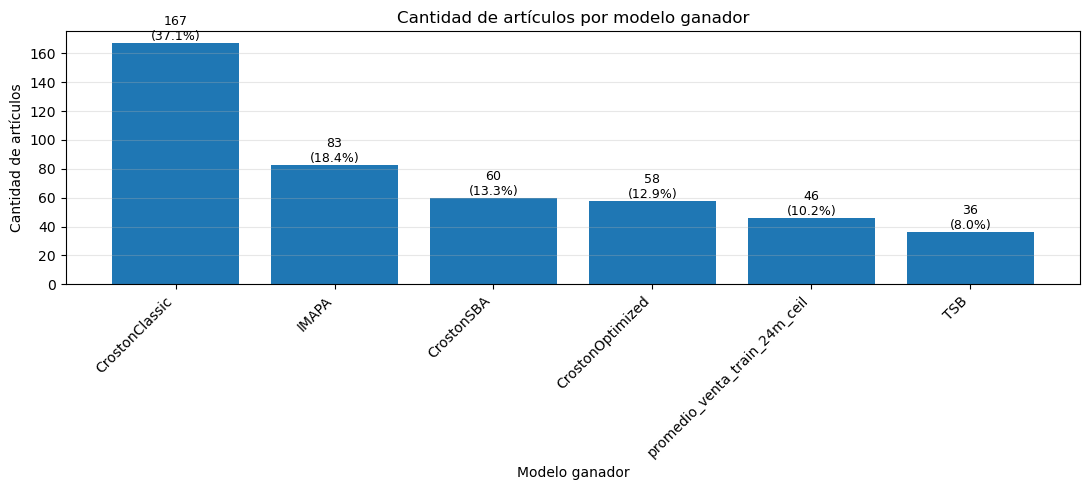

In [ ]:
# ============================================================
# Gráfico de barras - modelo ganador
# ============================================================

df_plot_modelo_ganador = df_segmentacion_modelo_ganador.sort_values(
    "cantidad_articulos",
    ascending=False
)

plt.figure(figsize=(11, 5))

plt.bar(
    df_plot_modelo_ganador["modelo_ganador"],
    df_plot_modelo_ganador["cantidad_articulos"]
)

plt.title("Cantidad de artículos por modelo ganador")
plt.xlabel("Modelo ganador")
plt.ylabel("Cantidad de artículos")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, fila in df_plot_modelo_ganador.reset_index(drop=True).iterrows():
    plt.text(
        i,
        fila["cantidad_articulos"],
        f"{int(fila['cantidad_articulos'])}\n({fila['porcentaje_articulos']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Resumen de modelos ganadores
# ============================================================

df_resumen_modelos_ganadores = (
    df_mejor_modelo_por_articulo
    .groupby("modelo_ganador")
    .agg(
        cantidad_articulos=("unique_id", "nunique"),
        WAPE_promedio=("WAPE_ranking", "mean"),
        WAPE_mediana=("WAPE_ranking", "median"),
        MAE_promedio=("MAE", "mean"),
        RMSE_promedio=("RMSE", "mean"),
        venta_real_total=("venta_real_total", "sum"),
        prediccion_total=("prediccion_total", "sum"),
        error_absoluto_total=("error_absoluto_total", "sum")
    )
    .reset_index()
    .sort_values("cantidad_articulos", ascending=False)
    .round(2)
)

df_resumen_modelos_ganadores

,modelo_ganador,cantidad_articulos,WAPE_promedio,WAPE_mediana,MAE_promedio,RMSE_promedio,venta_real_total,prediccion_total,error_absoluto_total
0,CrostonClassic,167,inf,140.00,4.58,5.81,4668.75,4290.0,4593.95
3,IMAPA,83,inf,133.33,5034.76,6772.80,3597423.36,3136782.0,2507309.34
2,CrostonSBA,60,inf,115.62,5309.15,6310.46,2989396.54,2995662.0,1911294.54
1,CrostonOptimized,58,inf,136.67,199.91,253.80,96111.21,76782.0,69567.37
5,promedio_venta_train_24m_ceil,46,inf,104.92,3761.56,4501.19,1560216.48,1668462.0,1038191.54
4,TSB,36,inf,128.38,3556.59,4781.03,1408132.36,944106.0,768223.16
